In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
deliveries=pd.read_csv('deliveries.csv')
matches=pd.read_csv('matches.csv')

In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [5]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [6]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [7]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [8]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [9]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [10]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [11]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [12]:
matches['date']=pd.to_datetime(matches['date'])
matches['season']=matches['season'].apply(lambda x:int (str(x)[:4]))
matches[['date','season']].head(10)
sorted(matches['season'].unique())

[np.int64(2007),
 np.int64(2009),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024)]

In [13]:
matches['id'].duplicated().sum()

np.int64(0)

In [14]:
dup_deliveries = deliveries.duplicated(subset=['match_id', 'inning', 'over', 'ball']).sum()

In [15]:
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Deccan Chargers': 'Deccan Chargers',       
    'Kochi Tuskers Kerala': 'Kochi Tuskers Kerala',  
    'Gujarat Lions': 'Gujarat Lions',           
    'Pune Warriors': 'Pune Warriors',           
}

for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(team_name_map)

for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(team_name_map)



In [16]:
sorted(matches['team1'].unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [17]:
deliveries['extras_type'] = deliveries['extras_type'].fillna('None')
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('None')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('None')
deliveries['fielder'] = deliveries['fielder'].fillna('None')

In [18]:
matches['winner'] = matches['winner'].fillna('No Result')

In [19]:
matches['city'] = matches['city'].fillna(matches['venue'].str.split(',').str[-1].str.strip())

In [20]:
matches['player_of_match']=matches['player_of_match'].fillna("No Award")

In [21]:
matches.isnull().sum()

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [22]:
deliveries.isnull().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [23]:
df=deliveries.merge(matches,left_on='match_id',right_on='id',how='left')
df.shape

(260920, 37)

In [24]:
matches.to_csv('matches_clean.csv', index=False)
deliveries.to_csv('deliveries_clean.csv', index=False)
df.to_csv('merged_clean.csv', index=False)

In [25]:
matches_per_season=matches.groupby('season')['id'].count().reset_index()

In [26]:
matches_per_season.columns=['season','match_count']

In [27]:
matches_per_season

,season,match_count
0,2007,58
1,2009,117
2,2011,73
3,2012,74
4,2013,76
5,2014,60
6,2015,59
7,2016,60
8,2017,59
9,2018,60


In [28]:
toss_decision=matches['toss_decision'].value_counts()

In [29]:
toss_decision

toss_decision
field    704
bat      391
Name: count, dtype: int64

In [30]:
toss_trend=matches.groupby(['season','toss_decision'])['id'].count().reset_index()
toss_trend.columns=['season','toss_decision','count']
toss_trend

,season,toss_decision,count
0,2007,bat,26
1,2007,field,32
2,2009,bat,74
3,2009,field,43
4,2011,bat,25
5,2011,field,48
6,2012,bat,37
7,2012,field,37
8,2013,bat,45
9,2013,field,31


In [31]:
matches['toss_winner_won']=matches['toss_winner']==matches['winner']
toss_win_rate=matches[matches['winner']!='No Result']['toss_winner_won'].mean()*100
print(f"Win rate when winning toss: {toss_win_rate:.2f}%")

Win rate when winning toss: 50.83%


In [32]:
toss_decision_win=matches[matches['winner']!= 'No Result'].groupby('toss_decision')['toss_winner_won'].mean()*100
toss_decision_win

toss_decision
bat      45.384615
field    53.857143
Name: toss_winner_won, dtype: float64

In [33]:
teams_win=matches[matches['winner']!='No Result']['winner'].value_counts().reset_index()
teams_win.columns=['team','wins']
teams_win

,team,wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bengaluru,123
4,Delhi Capitals,115
5,Rajasthan Royals,112
6,Punjab Kings,112
7,Sunrisers Hyderabad,88
8,Deccan Chargers,29
9,Gujarat Titans,28


In [34]:
team_matches = pd.concat([matches['team1'], matches['team2']]).value_counts().reset_index()
team_matches.columns = ['team', 'matches_played']
team_matches

,team,matches_played
0,Mumbai Indians,261
1,Royal Challengers Bengaluru,255
2,Delhi Capitals,252
3,Kolkata Knight Riders,251
4,Punjab Kings,246
5,Chennai Super Kings,238
6,Rajasthan Royals,221
7,Sunrisers Hyderabad,182
8,Deccan Chargers,75
9,Pune Warriors,46


In [35]:
team_stats = team_matches.merge(teams_win, on='team', how='left')
team_stats['wins'] = team_stats['wins'].fillna(0)
team_stats['win_pct'] = (team_stats['wins'] / team_stats['matches_played'] * 100).round(2)
team_stats = team_stats.sort_values('win_pct', ascending=False)
team_stats

,team,matches_played,wins,win_pct
10,Gujarat Titans,45,28,62.22
5,Chennai Super Kings,238,138,57.98
0,Mumbai Indians,261,144,55.17
11,Lucknow Super Giants,44,24,54.55
3,Kolkata Knight Riders,251,131,52.19
6,Rajasthan Royals,221,112,50.68
13,Rising Pune Supergiants,30,15,50.00
7,Sunrisers Hyderabad,182,88,48.35
1,Royal Challengers Bengaluru,255,123,48.24
2,Delhi Capitals,252,115,45.63


In [36]:
result_type = matches[matches['winner'] != 'No Result']['result'].value_counts()
result_type

result
wickets    578
runs       498
tie         14
Name: count, dtype: int64

In [37]:
runs_margin = matches[matches['result'] == 'runs']['result_margin'].describe()
wickets_margin = matches[matches['result'] == 'wickets']['result_margin'].describe()

runs_margin




count    498.000000
mean      30.104418
std       26.739844
min        1.000000
25%       11.000000
50%       22.000000
75%       41.000000
max      146.000000
Name: result_margin, dtype: float64

In [38]:
wickets_margin

count    578.000000
mean       6.192042
std        1.845733
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       10.000000
Name: result_margin, dtype: float64

In [39]:
venue_counts = matches['venue'].value_counts().head(10).reset_index()
venue_counts.columns = ['venue', 'matches_hosted']
venue_counts

,venue,matches_hosted
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Rajiv Gandhi International Stadium, Uppal",49
5,"MA Chidambaram Stadium, Chepauk",48
6,Sawai Mansingh Stadium,47
7,Dubai International Cricket Stadium,46
8,"Wankhede Stadium, Mumbai",45
9,"Punjab Cricket Association Stadium, Mohali",35


In [40]:
home_city={
    'Mumbai Indians':'Mumbai',
    'Chennai Super Kings':'Chennai',
    'Royal Challengers Bengaluru':'Bangalore',
    'Kolkata Knight Riders':'Kolkata',
    'Delhi Capitals':'Delhi',
    'Punjab Kings':'Chandigarh',
    'Rajasthan Royals':'Jaipur',
    'Sunrises Hyderabad':'Hyderabad',
    'Gujrat Titans':'Ahemdabad',
    'Lucknow Super Giants':'Lucknow'
}


In [41]:
matches['team1_home'] = matches.apply(
    lambda r: home_city.get(r['team1'], '') == r['city'], axis=1)

In [42]:
home_matches = matches[matches['team1_home'] == True].copy()
home_matches['home_team_won'] = home_matches['team1'] == home_matches['winner']
home_win_rate = home_matches['home_team_won'].mean() * 100
home_win_rate

np.float64(56.47321428571429)

In [43]:
super_overs = matches[matches['super_over'] == 'Y']
print(f"Total super over matches: {len(super_overs)}")

so_teams = pd.concat([super_overs['team1'], super_overs['team2']]).value_counts()
so_teams

Total super over matches: 14


Kolkata Knight Riders          4
Sunrisers Hyderabad            4
Mumbai Indians                 4
Delhi Capitals                 4
Punjab Kings                   4
Royal Challengers Bengaluru    3
Rajasthan Royals               3
Chennai Super Kings            1
Gujarat Lions                  1
Name: count, dtype: int64

In [44]:
pom = matches[matches['player_of_match'] != 'No Award']['player_of_match'].value_counts().head(15).reset_index()
pom.columns = ['player', 'awards']
pom

,player,awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,DA Warner,18
4,V Kohli,18
5,MS Dhoni,17
6,SR Watson,16
7,YK Pathan,16
8,RA Jadeja,16
9,AD Russell,15


In [45]:
top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().reset_index()
top_scorers.columns = ['batter', 'total_runs']
top_scorers = top_scorers.sort_values('total_runs', ascending=False).head(15)
top_scorers

,batter,total_runs
631,V Kohli,8014
512,S Dhawan,6769
477,RG Sharma,6630
147,DA Warner,6567
546,SK Raina,5536
374,MS Dhoni,5243
30,AB de Villiers,5181
124,CH Gayle,4997
501,RV Uthappa,4954
282,KD Karthik,4843


In [46]:
batter_balls = deliveries.groupby('batter')['ball'].count().reset_index()
batter_balls.columns = ['batter', 'balls_faced']

batter_runs = deliveries.groupby('batter')['batsman_runs'].sum().reset_index()
batter_runs.columns = ['batter', 'total_runs']

batter_stats = batter_runs.merge(batter_balls, on='batter')
batter_stats['strike_rate'] = (batter_stats['total_runs'] / batter_stats['balls_faced'] * 100).round(2)


batter_stats = batter_stats[batter_stats['balls_faced'] >= 500]
batter_stats = batter_stats.sort_values('strike_rate', ascending=False).head(15)
batter_stats

,batter,total_runs,balls_faced,strike_rate
39,AD Russell,2488,1515,164.22
208,H Klaasen,993,613,161.99
561,SP Narine,1534,984,155.89
396,N Pooran,1769,1143,154.77
323,LS Livingstone,939,609,154.19
203,GJ Maxwell,2772,1842,150.49
485,RM Patidar,799,534,149.63
70,Abhishek Sharma,1377,925,148.86
633,V Sehwag,2728,1833,148.83
30,AB de Villiers,5181,3487,148.58


In [47]:

season_runs = df.groupby('season')['batsman_runs'].sum().reset_index()
season_runs.columns = ['season', 'total_runs']


season_matches = matches.groupby('season')['id'].count().reset_index()
season_matches.columns = ['season', 'match_count']


season_batting = season_runs.merge(season_matches, on='season')
season_batting['avg_runs_per_match'] = (season_batting['total_runs'] / season_batting['match_count']).round(2)
season_batting

,season,total_runs,match_count,avg_runs_per_match
0,2007,16809,58,289.81
1,2009,33130,117,283.16
2,2011,19928,73,272.99
3,2012,21323,74,288.15
4,2013,21487,76,282.72
5,2014,17943,60,299.05
6,2015,17427,59,295.37
7,2016,17962,60,299.37
8,2017,17920,59,303.73
9,2018,19098,60,318.30


In [48]:
season_runs

,season,total_runs
0,2007,16809
1,2009,33130
2,2011,19928
3,2012,21323
4,2013,21487
5,2014,17943
6,2015,17427
7,2016,17962
8,2017,17920
9,2018,19098


In [49]:
season_matches

,season,match_count
0,2007,58
1,2009,117
2,2011,73
3,2012,74
4,2013,76
5,2014,60
6,2015,59
7,2016,60
8,2017,59
9,2018,60


In [50]:
season_batting

,season,total_runs,match_count,avg_runs_per_match
0,2007,16809,58,289.81
1,2009,33130,117,283.16
2,2011,19928,73,272.99
3,2012,21323,74,288.15
4,2013,21487,76,282.72
5,2014,17943,60,299.05
6,2015,17427,59,295.37
7,2016,17962,60,299.37
8,2017,17920,59,303.73
9,2018,19098,60,318.30


In [51]:
fours = deliveries[deliveries['batsman_runs'] == 4].groupby('batter')['batsman_runs'].count().reset_index()
fours.columns = ['batter', 'fours']
fours = fours.sort_values('fours', ascending=False).head(15)
fours

,batter,fours
416,S Dhawan,768
508,V Kohli,708
119,DA Warner,663
388,RG Sharma,599
441,SK Raina,506
158,G Gambhir,492
406,RV Uthappa,481
43,AM Rahane,479
230,KD Karthik,466
155,F du Plessis,422


In [52]:
sixes = deliveries[deliveries['batsman_runs'] == 6].groupby('batter')['batsman_runs'].count().reset_index()
sixes.columns = ['batter', 'sixes']
sixes = sixes.sort_values('sixes', ascending=False).head(15)
sixes

,batter,sixes
84,CH Gayle,359
324,RG Sharma,281
427,V Kohli,273
14,AB de Villiers,253
254,MS Dhoni,252
98,DA Warner,236
184,KA Pollard,224
23,AD Russell,209
387,SV Samson,206
365,SK Raina,204


In [53]:
df['is_four'] = df['batsman_runs'] == 4
df['is_six'] = df['batsman_runs'] == 6

boundaries_per_season = df.groupby('season')[['is_four', 'is_six']].sum().reset_index()
boundaries_per_season

,season,is_four,is_six
0,2007,1703,623
1,2009,3030,1095
2,2011,1916,639
3,2012,1911,733
4,2013,2054,681
5,2014,1563,715
6,2015,1611,692
7,2016,1633,639
8,2017,1612,706
9,2018,1652,872


In [54]:

def get_phase(over):
    if over <= 5:
        return 'Powerplay'
    elif over <= 14:
        return 'Middle'
    else:
        return 'Death'

deliveries['phase'] = deliveries['over'].apply(get_phase)


phase_runs = deliveries.groupby('phase')['total_runs'].sum().reset_index()
phase_balls = deliveries.groupby('phase')['ball'].count().reset_index()

phase_stats = phase_runs.merge(phase_balls, on='phase')
phase_stats.columns = ['phase', 'total_runs', 'total_balls']
phase_stats['run_rate'] = (phase_stats['total_runs'] / phase_stats['total_balls'] * 6).round(2)
phase_stats

,phase,total_runs,total_balls,run_rate
0,Death,93884,59463,9.47
1,Middle,150655,119552,7.56
2,Powerplay,103217,81905,7.56


In [55]:
deliveries['is_boundary'] = deliveries['batsman_runs'].isin([4, 6])

phase_boundary = deliveries.groupby('phase').agg(
    total_balls=('ball', 'count'),
    boundaries=('is_boundary', 'sum')
).reset_index()

phase_boundary['boundary_pct'] = (phase_boundary['boundaries'] / phase_boundary['total_balls'] * 100).round(2)
phase_boundary

,phase,total_balls,boundaries,boundary_pct
0,Death,59463,11506,19.35
1,Middle,119552,15903,13.30
2,Powerplay,81905,15492,18.91


In [56]:
extras = deliveries[deliveries['extras_type'] != 'None']['extras_type'].value_counts().reset_index()
extras.columns = ['extras_type', 'count']
print(extras)

  extras_type  count
0       wides   8380
1     legbyes   4001
2     noballs   1069
3        byes    673
4     penalty      2


In [57]:
extras_by_team = deliveries[deliveries['extras_type'] != 'None'].groupby(
    ['bowling_team', 'extras_type'])['extra_runs'].sum().reset_index()
extras_by_team = extras_by_team.sort_values('extra_runs', ascending=False)
print(extras_by_team.head(20))

                   bowling_team extras_type  extra_runs
37               Mumbai Indians       wides        1330
57  Royal Challengers Bengaluru       wides        1255
45                 Punjab Kings       wides        1157
49             Rajasthan Royals       wides        1121
12               Delhi Capitals       wides        1099
3           Chennai Super Kings       wides        1073
28        Kolkata Knight Riders       wides        1071
61          Sunrisers Hyderabad       wides         729
34               Mumbai Indians     legbyes         664
10               Delhi Capitals     legbyes         640
43                 Punjab Kings     legbyes         625
55  Royal Challengers Bengaluru     legbyes         613
26        Kolkata Knight Riders     legbyes         579
1           Chennai Super Kings     legbyes         559
47             Rajasthan Royals     legbyes         530
59          Sunrisers Hyderabad     legbyes         372
8               Deccan Chargers       wides     

In [58]:
wickets = deliveries[
    (deliveries['is_wicket'] == 1) & 
    (deliveries['dismissal_kind'] != 'run out')
]

top_wickets = wickets.groupby('bowler')['is_wicket'].count().reset_index()
top_wickets.columns = ['bowler', 'wickets']
top_wickets = top_wickets.sort_values('wickets', ascending=False).head(15)
top_wickets

,bowler,wickets
445,YS Chahal,205
297,PP Chawla,192
102,DJ Bravo,183
61,B Kumar,181
304,R Ashwin,181
379,SP Narine,180
7,A Mishra,174
372,SL Malinga,170
168,JJ Bumrah,168
319,RA Jadeja,160


In [59]:
wickets

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,phase,is_boundary
33,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,5,2,SC Ganguly,Z Khan,BB McCullum,0,0,0,None,1,SC Ganguly,caught,JH Kallis,Powerplay,False
74,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,12,1,RT Ponting,JH Kallis,BB McCullum,0,0,0,None,1,RT Ponting,caught,P Kumar,Middle,False
106,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,17,1,DJ Hussey,AA Noffke,BB McCullum,0,0,0,None,1,DJ Hussey,caught,CL White,Death,False
131,335982,2,Royal Challengers Bengaluru,Kolkata Knight Riders,1,1,R Dravid,I Sharma,W Jaffer,0,0,0,None,1,R Dravid,bowled,None,Powerplay,False
138,335982,2,Royal Challengers Bengaluru,Kolkata Knight Riders,2,2,V Kohli,AB Dinda,W Jaffer,0,0,0,None,1,V Kohli,bowled,None,Powerplay,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260826,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,14,1,H Klaasen,Harshit Rana,PJ Cummins,0,0,0,None,1,H Klaasen,bowled,None,Middle,False
260848,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,17,5,JD Unadkat,SP Narine,PJ Cummins,0,0,0,None,1,JD Unadkat,lbw,None,Death,False
260852,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,18,3,PJ Cummins,AD Russell,B Kumar,0,0,0,None,1,PJ Cummins,caught,MA Starc,Death,False
260861,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,1,2,SP Narine,PJ Cummins,Rahmanullah Gurbaz,0,0,0,None,1,SP Narine,caught,Shahbaz Ahmed,Powerplay,False


In [60]:

bowler_runs = deliveries.groupby('bowler')['total_runs'].sum().reset_index()
bowler_runs.columns = ['bowler', 'runs_conceded']

legal_balls = deliveries[~deliveries['extras_type'].isin(['wides', 'noballs'])]
bowler_balls = legal_balls.groupby('bowler')['ball'].count().reset_index()
bowler_balls.columns = ['bowler', 'balls_bowled']

bowler_economy = bowler_runs.merge(bowler_balls, on='bowler')
bowler_economy['overs_bowled'] = (bowler_economy['balls_bowled'] / 6).round(2)
bowler_economy['economy'] = (bowler_economy['runs_conceded'] / bowler_economy['overs_bowled']).round(2)

bowler_economy = bowler_economy[bowler_economy['balls_bowled'] >= 300]
bowler_economy = bowler_economy.sort_values('economy').head(15)
bowler_economy

,bowler,runs_conceded,balls_bowled,overs_bowled,economy
7,A Kumble,1089,965,160.83,6.77
147,GD McGrath,366,324,54.00,6.78
446,SP Narine,4672,4081,680.17,6.87
181,J Yadav,447,390,65.00,6.88
130,DL Vettori,894,777,129.50,6.90
263,M Muralitharan,1765,1528,254.67,6.93
377,RE van der Merwe,515,443,73.83,6.98
398,Rashid Khan,3340,2872,478.67,6.98
284,MJ Santner,428,366,61.00,7.02
176,J Botha,818,694,115.67,7.07


In [61]:
bowler_wickets = wickets.groupby('bowler')['is_wicket'].count().reset_index()
bowler_wickets.columns = ['bowler', 'wickets']

bowler_stats = bowler_economy.merge(bowler_wickets, on='bowler', how='left')
bowler_stats['wickets'] = bowler_stats['wickets'].fillna(0)


bowler_stats['bowling_avg'] = (bowler_stats['runs_conceded'] / bowler_stats['wickets']).round(2)

bowler_stats['bowling_sr'] = (bowler_stats['balls_bowled'] / bowler_stats['wickets']).round(2)

bowler_stats = bowler_stats[bowler_stats['wickets'] >= 20]
bowler_stats = bowler_stats.sort_values('bowling_avg')
bowler_stats[['bowler', 'wickets', 'economy', 'bowling_avg', 'bowling_sr']].head(15)

,bowler,wickets,economy,bowling_avg,bowling_sr
7,Rashid Khan,149,6.98,22.42,19.28
0,A Kumble,45,6.77,24.20,21.44
6,RE van der Merwe,21,6.98,24.52,21.10
13,MM Ali,35,7.12,25.71,21.66
2,SP Narine,180,6.87,25.96,22.67
10,DW Steyn,97,7.10,26.63,22.49
14,Harbhajan Singh,150,7.20,27.34,22.77
11,R Sharma,40,7.11,27.50,23.20
5,M Muralitharan,64,6.93,27.58,23.88
4,DL Vettori,28,6.90,31.93,27.75


In [62]:
powerplay_balls = deliveries[deliveries['over'] <= 5]

pp_economy = powerplay_balls.groupby('bowler')['total_runs'].sum().reset_index()
pp_balls = powerplay_balls[~powerplay_balls['extras_type'].isin(['wides', 'noballs'])].groupby('bowler')['ball'].count().reset_index()

pp_stats = pp_economy.merge(pp_balls, on='bowler')
pp_stats.columns = ['bowler', 'runs', 'balls']
pp_stats['economy'] = (pp_stats['runs'] / (pp_stats['balls'] / 6)).round(2)
pp_stats = pp_stats[pp_stats['balls'] >= 60]
pp_stats = pp_stats.sort_values('economy').head(10)
pp_stats

,bowler,runs,balls,economy
29,AG Murtaza,52,78,4.00
111,FH Edwards,61,78,4.69
7,A Kumble,90,108,5.00
366,SMSM Senanayake,111,126,5.29
14,A Symonds,110,114,5.79
2,A Chandila,139,144,5.79
116,GD McGrath,218,222,5.89
150,JC Archer,393,396,5.95
393,T Thushara,60,60,6.00
126,HF Gurney,66,66,6.00


In [63]:
death_balls = deliveries[deliveries['over'] >= 16]

death_economy = death_balls.groupby('bowler')['total_runs'].sum().reset_index()
death_pp_balls = death_balls[~death_balls['extras_type'].isin(['wides', 'noballs'])].groupby('bowler')['ball'].count().reset_index()

death_stats = death_economy.merge(death_pp_balls, on='bowler')
death_stats.columns = ['bowler', 'runs', 'balls']
death_stats['economy'] = (death_stats['runs'] / (death_stats['balls'] / 6)).round(2)
death_stats = death_stats[death_stats['balls'] >= 60]
death_stats = death_stats.sort_values('economy').head(10)
death_stats

,bowler,runs,balls,economy
213,M Theekshana,74,66,6.73
369,Sohail Tanvir,110,96,6.88
93,DE Bollinger,268,210,7.66
309,Rashid Khan,408,312,7.85
174,KH Pandya,123,94,7.85
203,M Ashwin,95,72,7.92
348,SP Narine,1003,739,8.14
341,SL Malinga,1252,917,8.19
205,M Kartik,122,88,8.32
4,A Kumble,148,106,8.38


In [64]:
dismissals = deliveries[deliveries['is_wicket'] == 1]

dismissal_types = dismissals['dismissal_kind'].value_counts().reset_index()
dismissal_types.columns = ['dismissal_kind', 'count']
dismissal_types['percentage'] = (dismissal_types['count'] / dismissal_types['count'].sum() * 100).round(2)
dismissal_types

,dismissal_kind,count,percentage
0,caught,8063,62.26
1,bowled,2212,17.08
2,run out,1114,8.60
3,lbw,800,6.18
4,caught and bowled,367,2.83
5,stumped,358,2.76
6,retired hurt,15,0.12
7,hit wicket,15,0.12
8,obstructing the field,3,0.02
9,retired out,3,0.02


In [65]:
season_bowler = df.groupby(['season', 'bowler'])['total_runs'].sum().reset_index()
season_legal = df[~df['extras_type'].isin(['wides', 'noballs'])].groupby(['season', 'bowler'])['ball'].count().reset_index()
season_bowler_stats = season_bowler.merge(season_legal, on=['season', 'bowler'])
season_bowler_stats.columns = ['season', 'bowler', 'runs', 'balls']
season_bowler_stats['economy'] = (season_bowler_stats['runs'] / (season_bowler_stats['balls'] / 6)).round(2)
season_bowler_stats = season_bowler_stats[season_bowler_stats['balls'] >= 60]
best_per_season = season_bowler_stats.loc[season_bowler_stats.groupby('season')['economy'].idxmin()]
best_per_season = best_per_season.sort_values('season')
best_per_season[['season', 'bowler', 'economy']]

,season,bowler,economy
73,2007,SC Ganguly,6.60
103,2009,A Singh,5.71
337,2011,R Sharma,5.56
492,2012,SP Narine,5.61
628,2013,SP Narine,5.52
648,2014,AR Patel,6.42
812,2015,R Ashwin,5.87
859,2016,CH Gayle,6.50
1010,2017,Mohammad Nabi,5.36
1091,2018,IS Sodhi,5.96


In [66]:
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

C:\Users\aadit\AppData\Local\Temp\ipykernel_8832\2031920543.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=matches_per_season, x='season', y='match_count', palette='viridis')


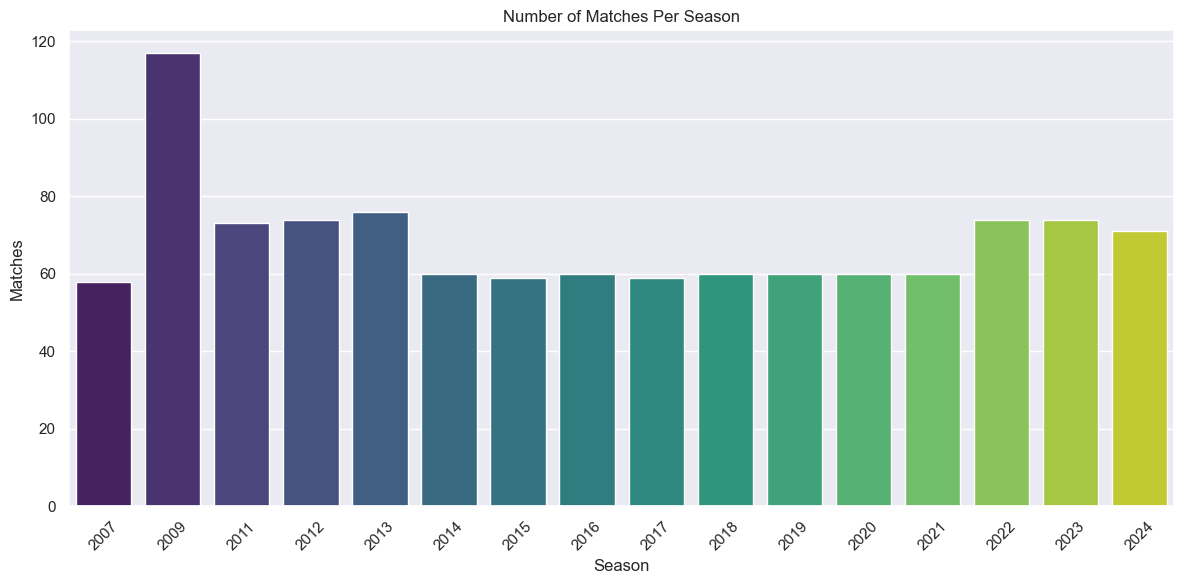

In [67]:
plt.figure()
sns.barplot(data=matches_per_season, x='season', y='match_count', palette='viridis')
plt.title('Number of Matches Per Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

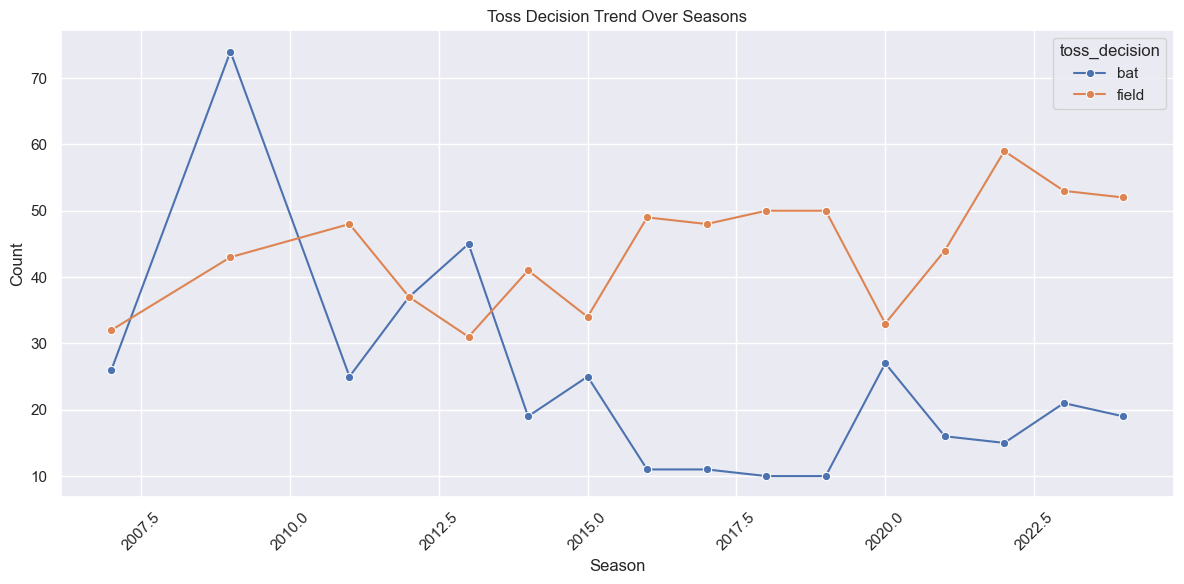

In [68]:
plt.figure()
sns.lineplot(data=toss_trend, x='season', y='count', hue='toss_decision', marker='o')
plt.title('Toss Decision Trend Over Seasons')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_8832\1891034378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_stats.sort_values('win_pct', ascending=False),


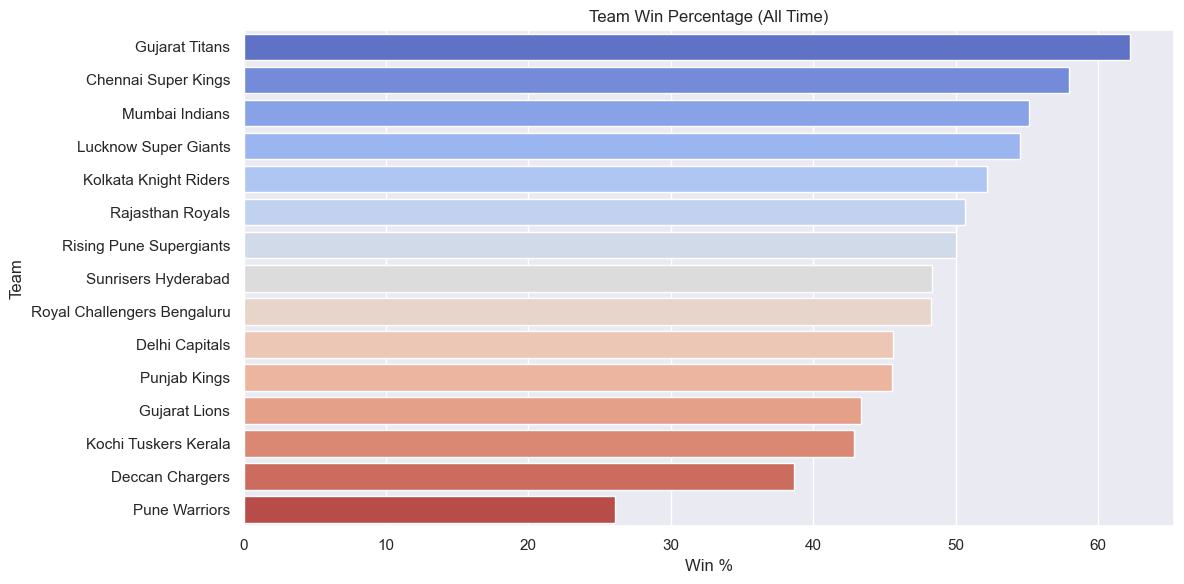

In [69]:
plt.figure()
sns.barplot(data=team_stats.sort_values('win_pct', ascending=False), 
            x='win_pct', y='team', palette='coolwarm')
plt.title('Team Win Percentage (All Time)')
plt.xlabel('Win %')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_8832\2132194966.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_scorers, x='total_runs', y='batter', palette='magma')


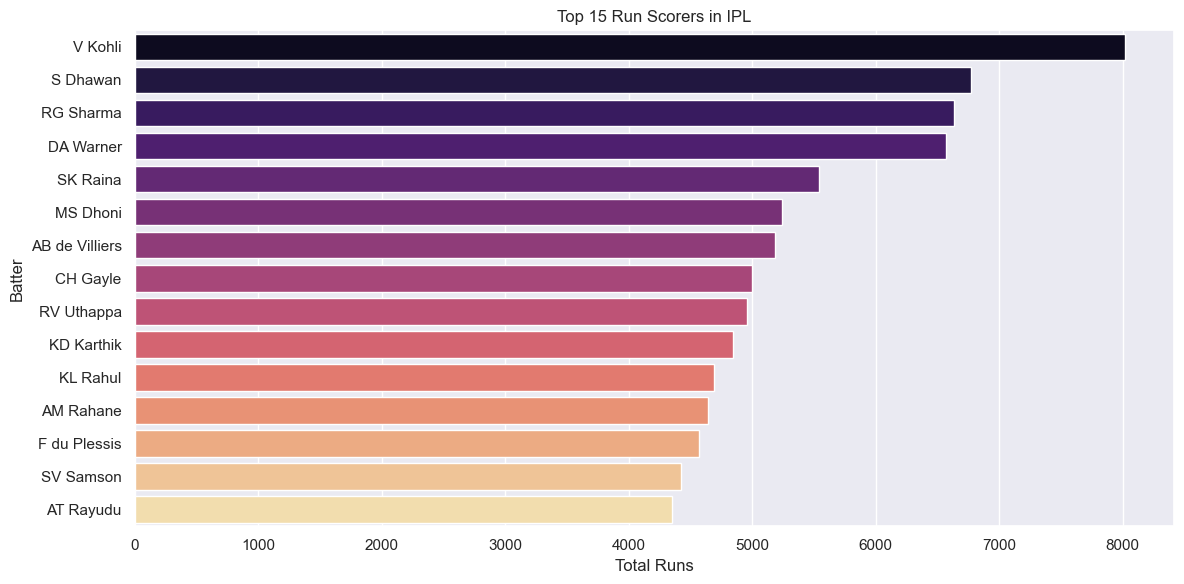

In [70]:
plt.figure()
sns.barplot(data=top_scorers, x='total_runs', y='batter', palette='magma')
plt.title('Top 15 Run Scorers in IPL')
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_8832\624257230.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_wickets, x='wickets', y='bowler', palette='Blues_r')


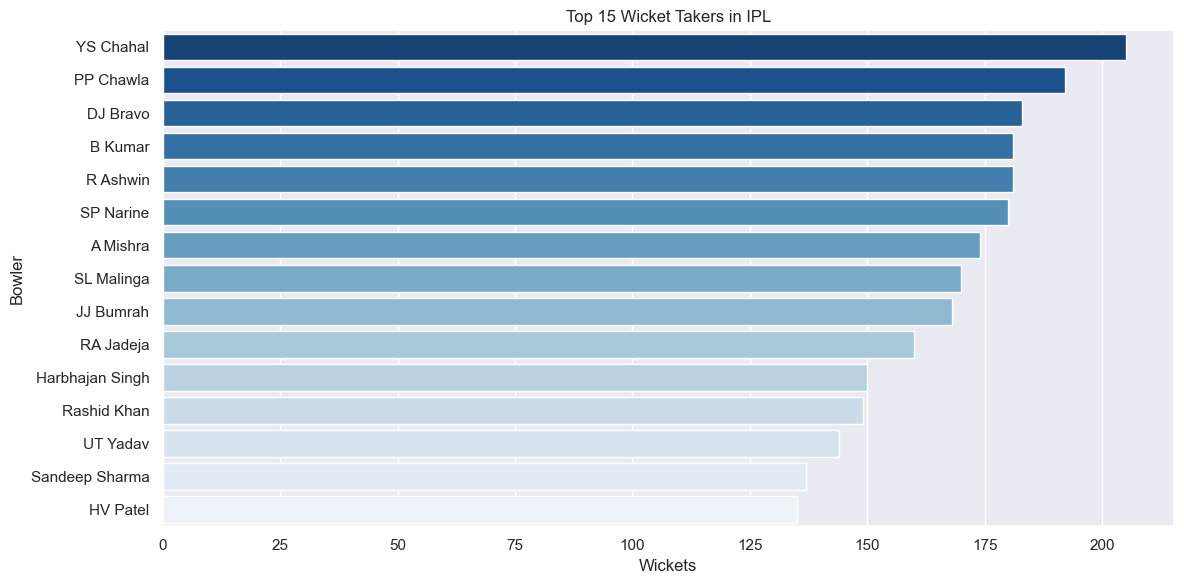

In [71]:
plt.figure()
sns.barplot(data=top_wickets, x='wickets', y='bowler', palette='Blues_r')
plt.title('Top 15 Wicket Takers in IPL')
plt.xlabel('Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

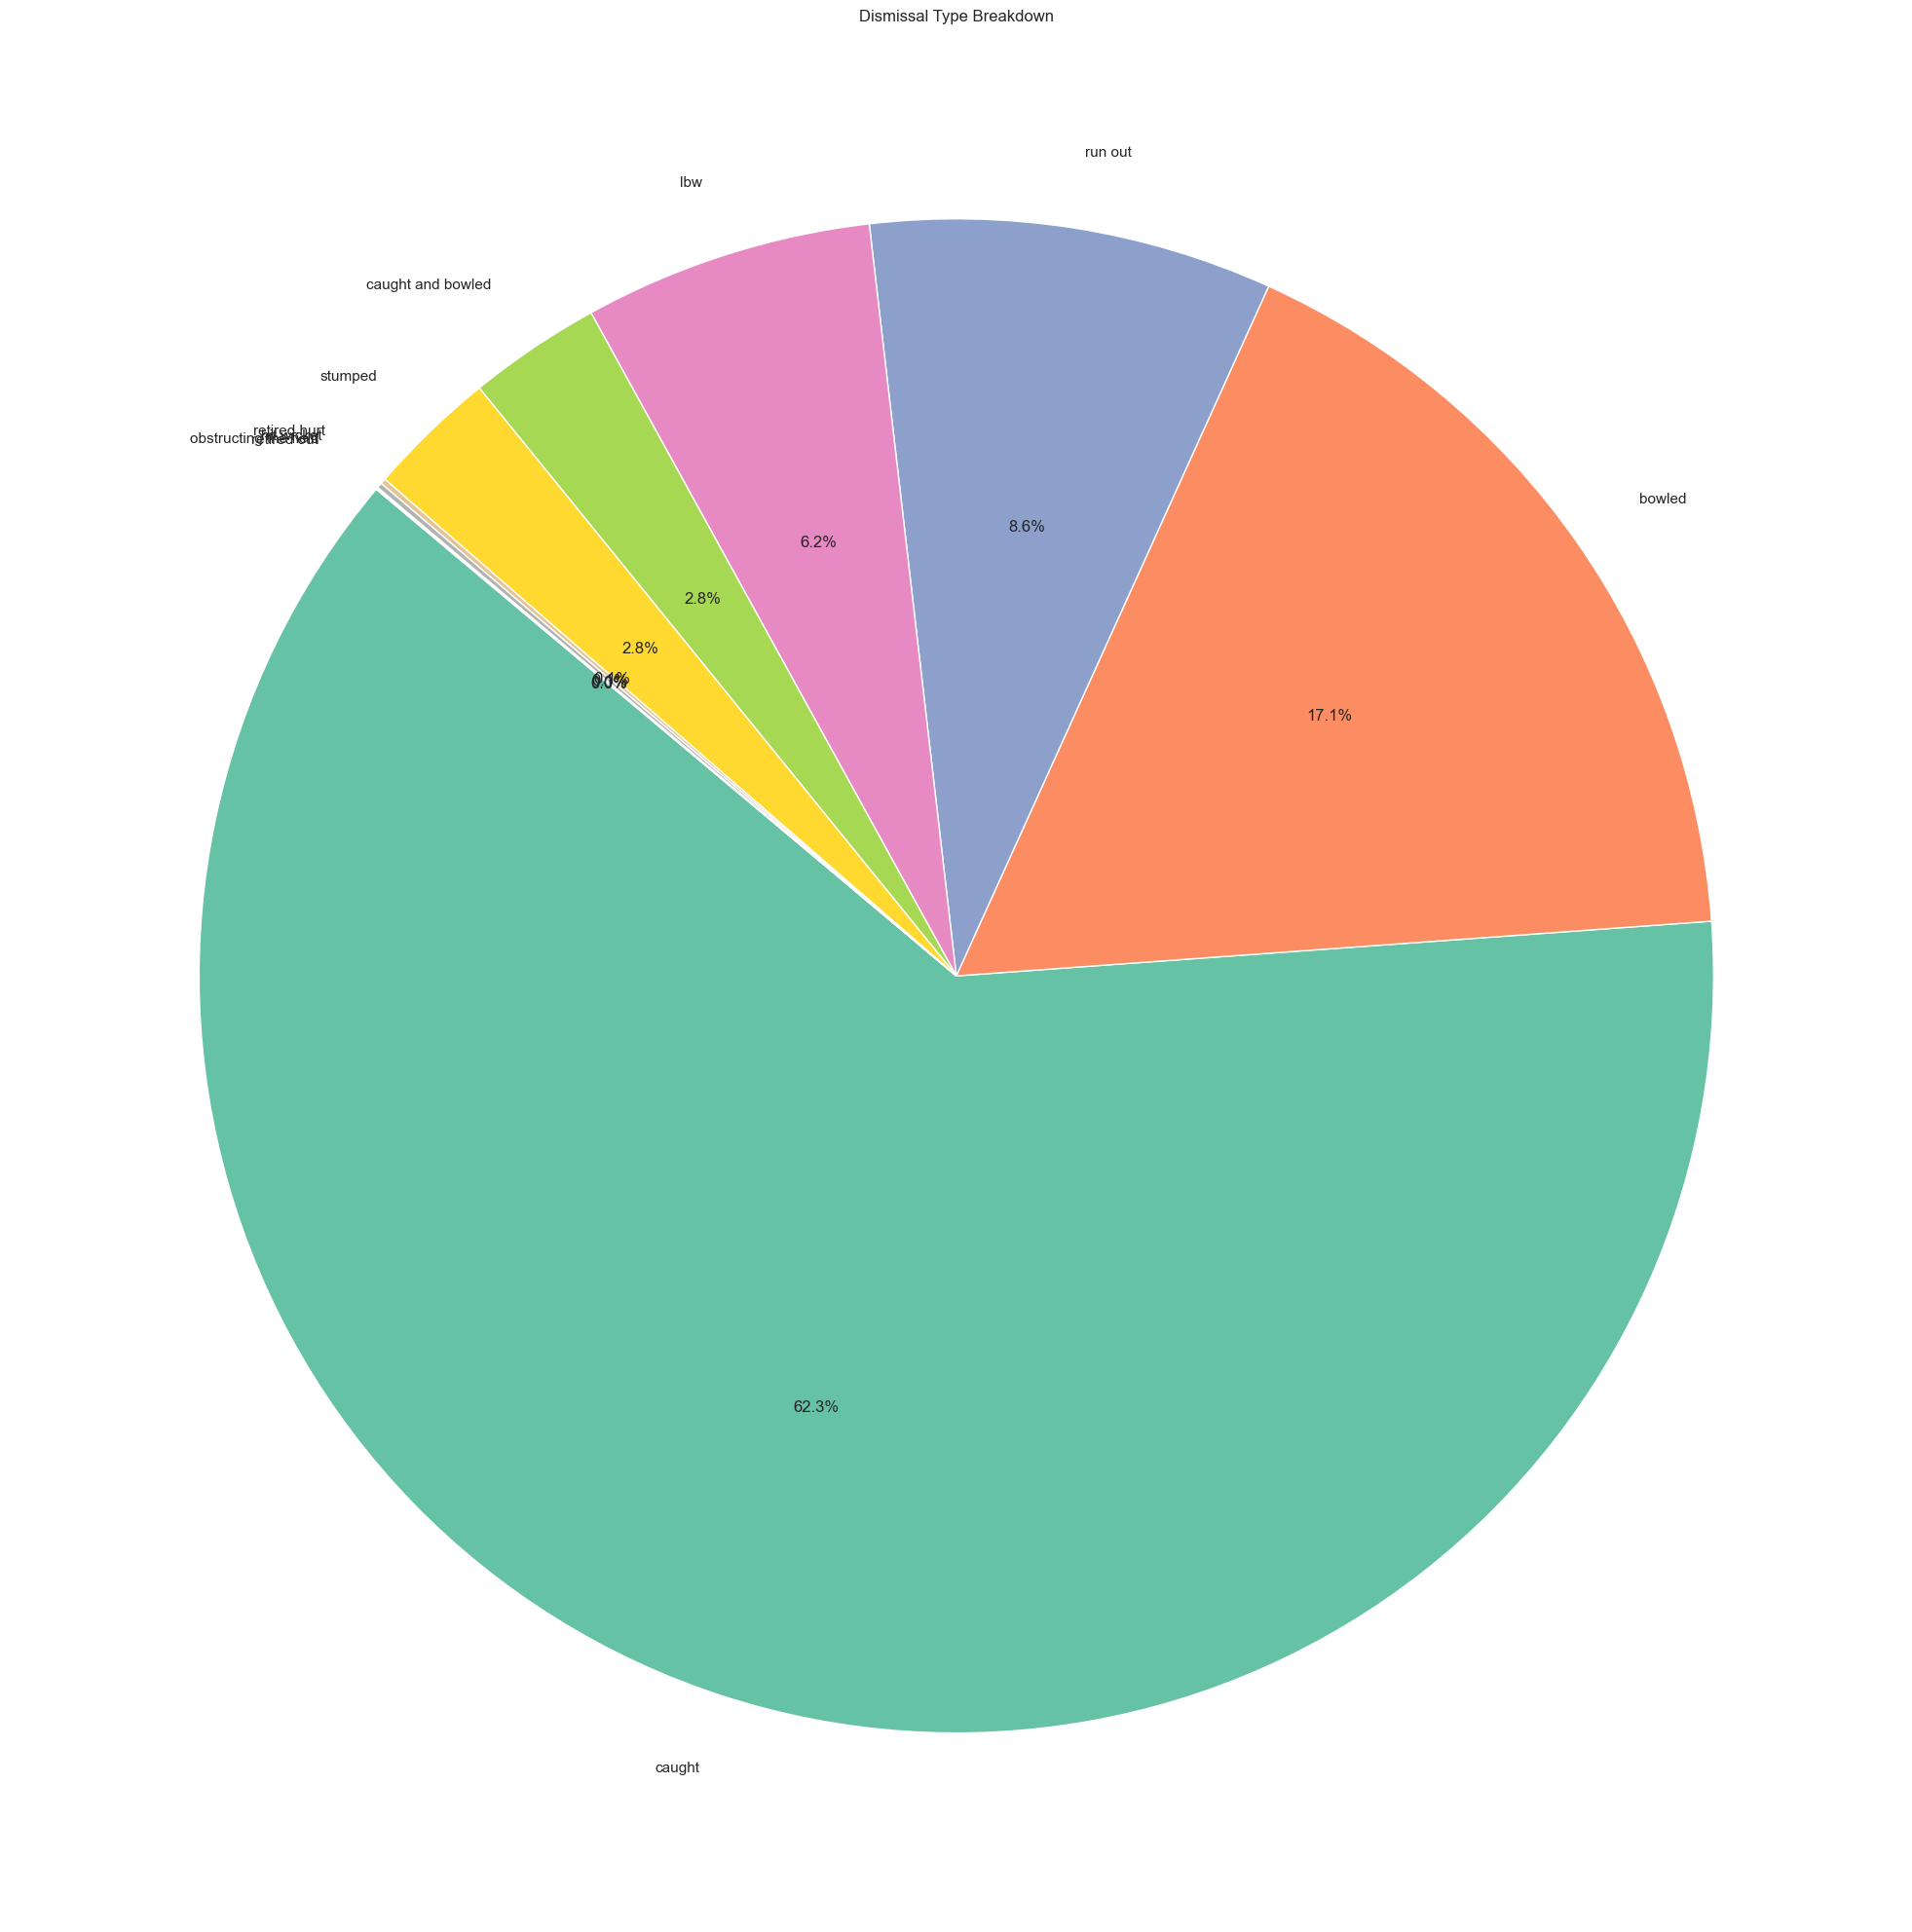

In [72]:
plt.figure(figsize=(20,20))
plt.pie(dismissal_types['count'], 
        labels=dismissal_types['dismissal_kind'], 
        autopct='%1.1f%%', 
        startangle=140,
        colors=sns.color_palette('Set2'))
plt.title('Dismissal Type Breakdown')
plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_8832\4154615986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=phase_stats, x='phase', y='run_rate', order=order, palette='rocket')


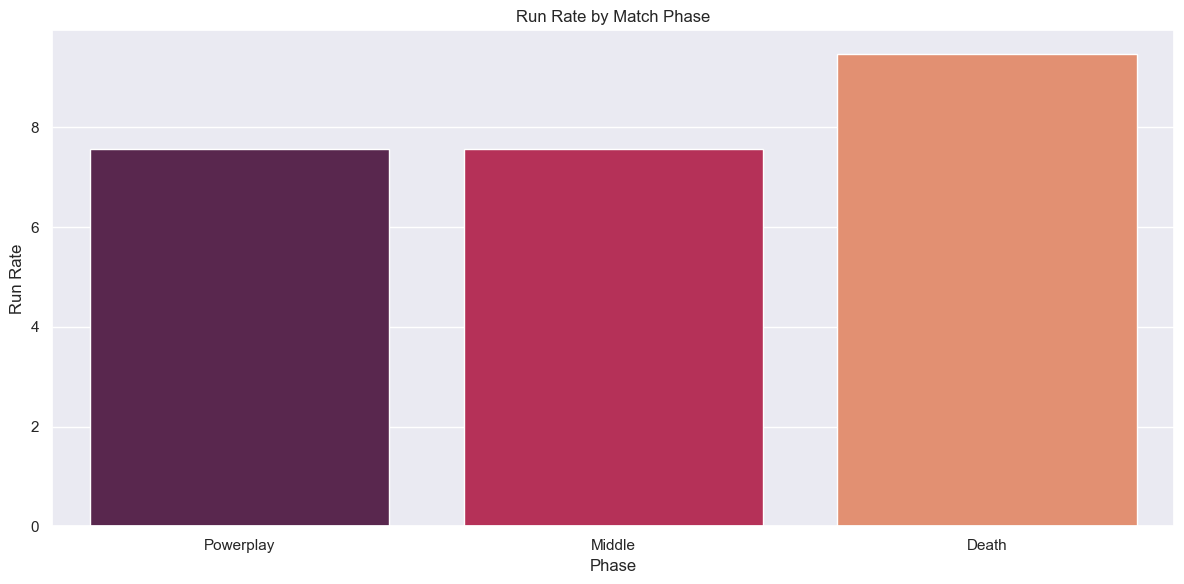

In [73]:
plt.figure()
order = ['Powerplay', 'Middle', 'Death']
sns.barplot(data=phase_stats, x='phase', y='run_rate', order=order, palette='rocket')
plt.title('Run Rate by Match Phase')
plt.xlabel('Phase')
plt.ylabel('Run Rate')
plt.tight_layout()
plt.show()

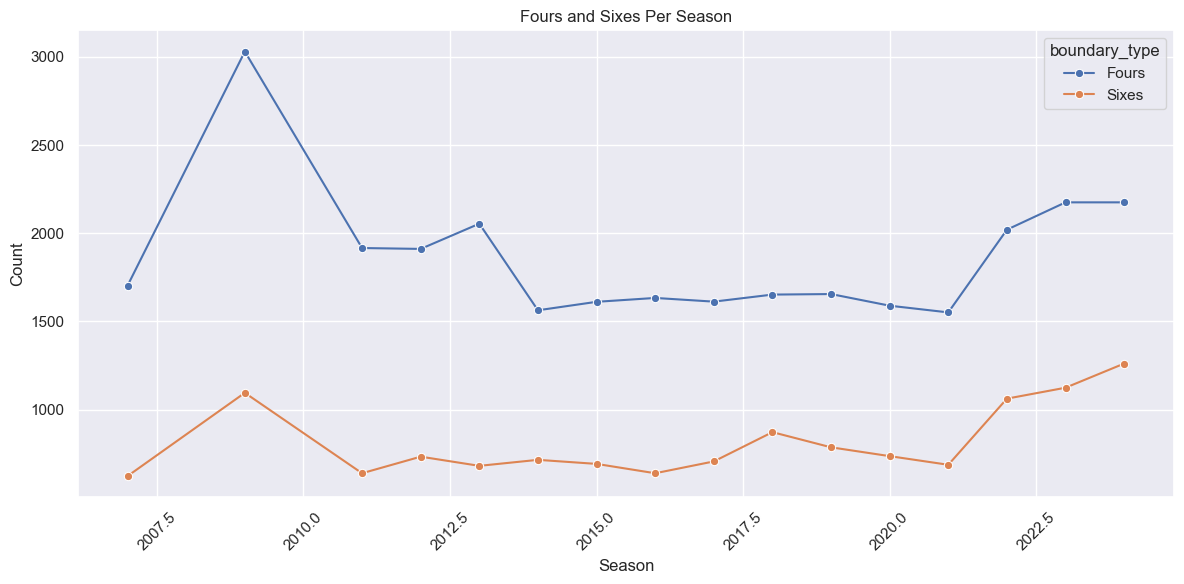

In [74]:
boundaries_per_season_melted = boundaries_per_season.melt(
    id_vars='season', 
    value_vars=['is_four', 'is_six'], 
    var_name='boundary_type', 
    value_name='count'
)
boundaries_per_season_melted['boundary_type'] = boundaries_per_season_melted['boundary_type'].replace({
    'is_four': 'Fours', 
    'is_six': 'Sixes'
})

plt.figure()
sns.lineplot(data=boundaries_per_season_melted, x='season', y='count', hue='boundary_type', marker='o')
plt.title('Fours and Sixes Per Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_8832\3234818063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sixes.head(10), x='sixes', y='batter', palette='flare')


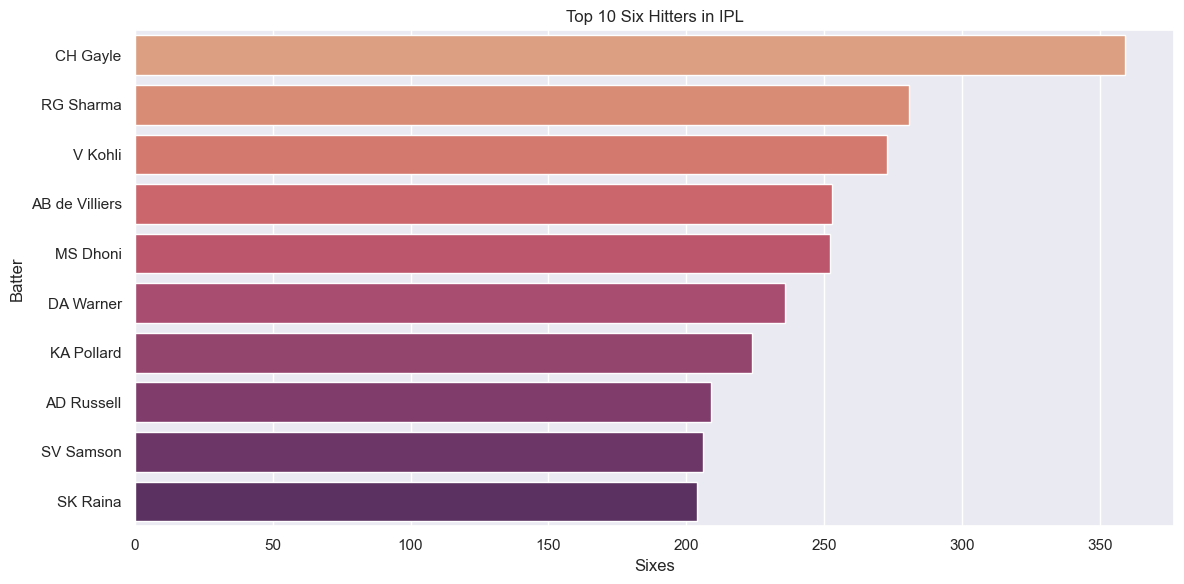

In [75]:
plt.figure()
sns.barplot(data=sixes.head(10), x='sixes', y='batter', palette='flare')
plt.title('Top 10 Six Hitters in IPL')
plt.xlabel('Sixes')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_8832\3234818063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sixes.head(10), x='sixes', y='batter', palette='flare')


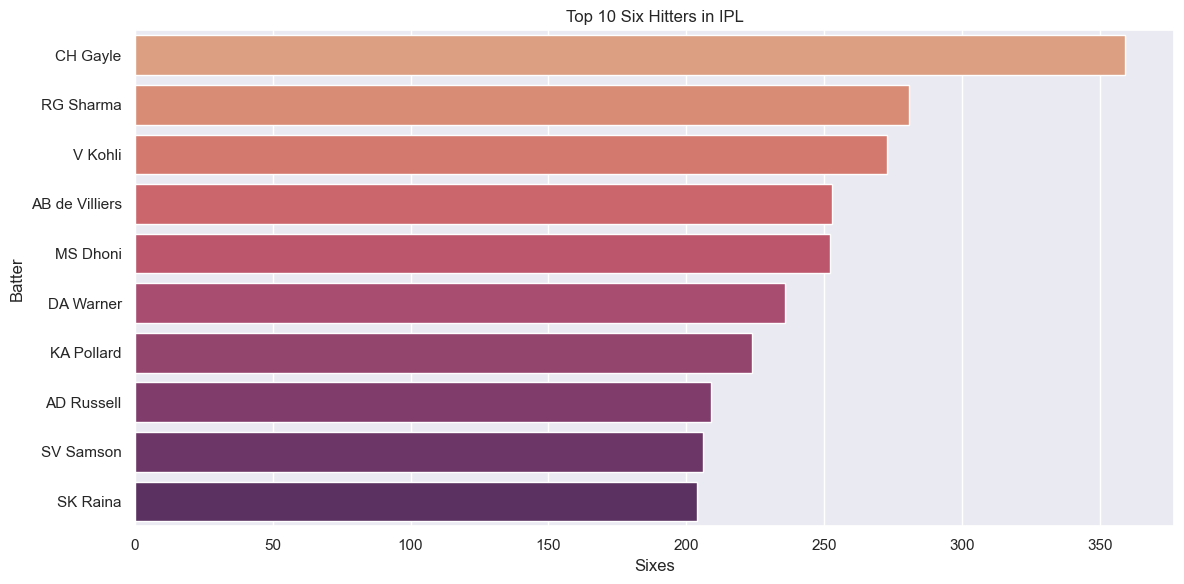

In [76]:
plt.figure()
sns.barplot(data=sixes.head(10), x='sixes', y='batter', palette='flare')
plt.title('Top 10 Six Hitters in IPL')
plt.xlabel('Sixes')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_8832\2309866803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bowler_economy.head(10), x='economy', y='bowler', palette='crest')


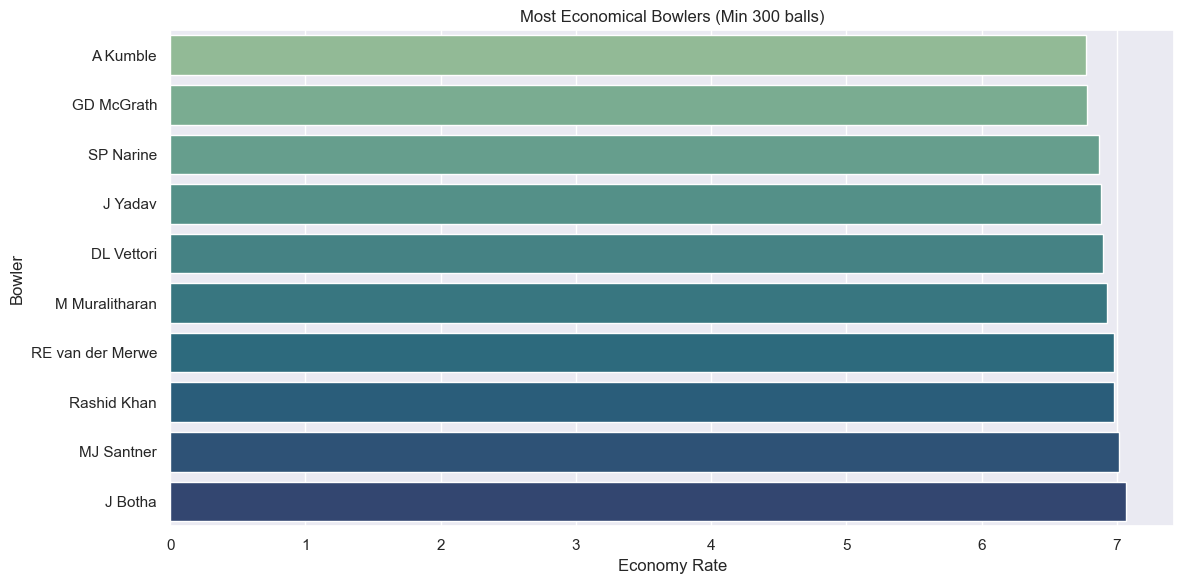

In [77]:
plt.figure()
sns.barplot(data=bowler_economy.head(10), x='economy', y='bowler', palette='crest')
plt.title('Most Economical Bowlers (Min 300 balls)')
plt.xlabel('Economy Rate')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

**Season and Match Trends**
IPL has grown a lot over the years. Early seasons had around 58 to 60 matches but recent seasons touch 70 to 74 matches thanks to more teams being added. The 2020/21 season was a bit of an outlier since it had fewer matches and was played entirely in the UAE because of COVID. Gujarat Titans and Lucknow Super Giants came in from 2022 which brought the total franchises to 10.

**Toss Analysis**
Winning the toss really doesn't matter as much as people think. The win rate after winning a toss is only around 51% which is basically a coin flip. What's more interesting is how team strategies have changed over the years. Back in 2008 to 2012 most teams preferred to bat first but from around 2015 onwards almost everyone started choosing to field. And that shift makes sense because teams that chose to field after winning the toss ended up winning more matches which confirms that chasing is the smarter approach in modern IPL.

**Team Performance**
Mumbai Indians stand out as the most successful franchise overall with the most wins and a consistently strong win percentage season after season. Chennai Super Kings are remarkable for a different reason which is their consistency. Even after missing two full seasons in 2016 and 2017 they came back and maintained one of the best win percentages in the league. Royal Challengers Bengaluru are an interesting case because they have some of the highest run totals in IPL history but their win percentage tells a different story which points to strong batting but a lack of balance across the squad. The defunct teams like Kochi Tuskers Kerala, Pune Warriors and Deccan Chargers all had poor win records and that probably played into why they eventually left the league. Gujarat Titans on the other hand have been surprisingly good for a team that only recently joined.

**Winning Margins**
When a team wins by runs the margin tends to be quite large because a defending team can bowl the opposition out cheaply. But when a team wins by wickets the margin can be as small as 1 wicket which makes those games feel much closer. Super overs are very rare in IPL which tells you that most games do produce a clear winner without needing that extra drama.

**Venue Analysis**
Wankhede Stadium in Mumbai and Eden Gardens in Kolkata are the two most used venues in the tournament which also happen to be home to the two most successful franchises. Home advantage does exist but it is not overwhelming. Teams win roughly 52 to 55 percent of their home games which is a slight edge but nothing decisive. Venues in Mumbai and Kolkata tend to heavily favor chasing teams especially in evening games because the dew makes it harder to grip the ball and bowl effectively in the second innings.

**Batting Insights**
Virat Kohli is the all time leading run scorer in IPL and it is not particularly close. Chris Gayle and AB de Villiers are in a league of their own when it comes to hitting sixes reflecting just how destructive they were at their peak. One of the clearest trends in the data is that batting scores have gone up every single season. The average runs per match in 2024 is dramatically higher than in 2008 which shows how much the game has evolved in terms of batting aggression, better bats and smarter shot selection. The powerplay produces the most boundaries because fielding restrictions force teams to attack. The middle overs slow things down as spinners come on and batters try to build a platform. The death overs are where everything explodes again with the highest run rates of any phase.

**Bowling Insights**
Lasith Malinga and Dwayne Bravo dominate the wicket taking charts and both are famous for being exceptional in the death overs. The most common way batters get out in IPL is caught which makes sense given how much aerial hitting happens in T20 cricket. Bowled and LBW together make up around 20 to 25 percent of dismissals while run outs account for roughly 8 to 10 percent showing that batters take a lot of risks between the wickets. Bowling in the death overs is genuinely the hardest skill in IPL. Economy rates jump significantly in overs 16 to 20 compared to the rest of the innings. Spinners are most effective in the middle overs where they consistently put the brakes on scoring.

**Phase-wise Insights**
The powerplay is aggressive and boundary heavy driven entirely by the fact that only two fielders can be outside the 30 yard circle. The middle overs are where the real tactical battle happens between spinners and set batters trying to accelerate without losing wickets. The death overs are pure chaos in the best way possible with batters swinging for everything and bowlers trying every trick in their arsenal. Run rates in the death overs are nearly 20 to 25 percent higher than in any other phase.

**Advanced Insights**
The trend of chasing teams winning has become stronger over the seasons going from around 48 percent in the early years to over 55 percent in recent seasons. This is a big deal because it completely changes how captains think about the toss. The dew factor in evening games plays a massive role in this since bowling becomes much harder in the second innings. The Mumbai Indians versus Chennai Super Kings rivalry is the biggest in IPL history in terms of matches played and it is remarkably even which makes every game between them feel special. Players like Virat Kohli, Rohit Sharma and MS Dhoni show incredible consistency across 10 or more seasons which separates the true legends from the one season wonders. Teams that concede a lot of extras tend to win fewer matches which shows how much discipline in bowling actually matters.

**Overall Takeaway**
If there is one thing this data makes crystal clear it is that IPL has evolved into a chasing game. Win the toss, put the opposition in, and chase the target. Death bowling is the single most impactful skill a team can have and the teams that get it right consistently end up winning titles. Batting has transformed completely over 17 seasons and the run rates of today would have seemed impossible back in 2008. And above everything else consistency beats individual brilliance every single time which is exactly why Mumbai Indians and Chennai Super Kings have the trophy cabinet they do.

In [78]:
ml_data=matches[['season','city','team1','team2','toss_winner','toss_decision','winner']].copy()
ml_data.shape

(1095, 7)

In [79]:
ml_data.head(10)

,season,city,team1,team2,toss_winner,toss_decision,winner
0,2007,Bangalore,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders
1,2007,Chandigarh,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings
2,2007,Delhi,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals
3,2007,Mumbai,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru
4,2007,Kolkata,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders
5,2007,Jaipur,Rajasthan Royals,Punjab Kings,Punjab Kings,bat,Rajasthan Royals
6,2007,Hyderabad,Deccan Chargers,Delhi Capitals,Deccan Chargers,bat,Delhi Capitals
7,2007,Chennai,Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,Chennai Super Kings
8,2007,Hyderabad,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals
9,2007,Chandigarh,Punjab Kings,Mumbai Indians,Mumbai Indians,field,Punjab Kings


In [80]:
ml_data=ml_data.dropna()

In [81]:
ml_data.shape

(1095, 7)

In [82]:
ml_data['result']=(ml_data['winner']==ml_data['team1']).astype(int)

In [83]:
ml_data['result'].value_counts()

result
1    555
0    540
Name: count, dtype: int64

In [84]:
ml_data[['team1','team2','winner','result']].head()

,team1,team2,winner,result
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,0
1,Punjab Kings,Chennai Super Kings,Chennai Super Kings,0
2,Delhi Capitals,Rajasthan Royals,Delhi Capitals,1
3,Mumbai Indians,Royal Challengers Bengaluru,Royal Challengers Bengaluru,0
4,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,1


In [85]:
ml_data['toss_advantage'] = (ml_data['toss_winner'] == ml_data['team1']).astype(int)
ml_data = ml_data.drop(columns=['toss_advantage'])

In [86]:
ml_data=ml_data.drop(columns=["winner"])

In [87]:
ml_data.columns

Index(['season', 'city', 'team1', 'team2', 'toss_winner', 'toss_decision',
       'result'],
      dtype='object')

In [99]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
import ipywidgets as widgets
from IPython.display import display

In [100]:
le=LabelEncoder()

In [101]:
ml_data.head()

,season,city,team1,team2,toss_winner,toss_decision,result
0,2007,Bangalore,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,0
1,2007,Chandigarh,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,0
2,2007,Delhi,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,1
3,2007,Mumbai,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,0
4,2007,Kolkata,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,1


In [102]:
ml_data.select_dtypes(include='object').columns.tolist()

['city', 'team1', 'team2', 'toss_winner', 'toss_decision']

In [103]:
ml_data.describe

<bound method NDFrame.describe of       season        city                        team1  \
0       2007   Bangalore  Royal Challengers Bengaluru   
1       2007  Chandigarh                 Punjab Kings   
2       2007       Delhi               Delhi Capitals   
3       2007      Mumbai               Mumbai Indians   
4       2007     Kolkata        Kolkata Knight Riders   
...      ...         ...                          ...   
1090    2024   Hyderabad                 Punjab Kings   
1091    2024   Ahmedabad          Sunrisers Hyderabad   
1092    2024   Ahmedabad  Royal Challengers Bengaluru   
1093    2024     Chennai          Sunrisers Hyderabad   
1094    2024     Chennai          Sunrisers Hyderabad   

                            team2                  toss_winner toss_decision  \
0           Kolkata Knight Riders  Royal Challengers Bengaluru         field   
1             Chennai Super Kings          Chennai Super Kings           bat   
2                Rajasthan Royals        

In [104]:
ml_data.shape


(1095, 7)

In [105]:
ml_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   season         1095 non-null   int64 
 1   city           1095 non-null   object
 2   team1          1095 non-null   object
 3   team2          1095 non-null   object
 4   toss_winner    1095 non-null   object
 5   toss_decision  1095 non-null   object
 6   result         1095 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 60.0+ KB


In [112]:

encoders = {}
categorical_cols = ['city', 'team1', 'team2', 'toss_winner', 'toss_decision']

ml_data_raw = matches[['season', 'city', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner']].copy()
ml_data_raw = ml_data_raw.dropna()
ml_data_raw['result'] = (ml_data_raw['winner'] == ml_data_raw['team1']).astype(int)
ml_data_raw = ml_data_raw.drop(columns=['winner'])

for col in categorical_cols:
    le = LabelEncoder()
    ml_data_raw[col] = le.fit_transform(ml_data_raw[col])
    encoders[col] = le

X = ml_data_raw.drop(columns=['result'])
y = ml_data_raw['result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)


In [113]:
print(" ------- LOGISTIC REGRESSION ------")
print(f"Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, lr_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

 ------- LOGISTIC REGRESSION ------
Accuracy: 52.51%
F1 Score: 0.48

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.68      0.56        98
           1       0.61      0.40      0.48       121

    accuracy                           0.53       219
   macro avg       0.54      0.54      0.52       219
weighted avg       0.55      0.53      0.52       219



In [114]:
cm = confusion_matrix(y_test, lr_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[67 31]
 [73 48]]


In [115]:
teams = sorted(encoders['team1'].classes_)
cities = sorted(encoders['city'].classes_)

team1_dropdown = widgets.Dropdown(options=teams, description='Team 1:')
team2_dropdown = widgets.Dropdown(options=teams, description='Team 2:')
city_dropdown = widgets.Dropdown(options=cities, description='City:')
output = widgets.Output()

disclaimer = widgets.HTML(
    value="""
    <b>⚠️ Disclaimer:</b> Predictions are based on historical IPL data from 2008 to 2024. 
    Results may not reflect current team compositions, player form or 2025/2026 season performance.
    <br><br>
    <b>📌 Note:</b> Enter the <b>Home Team</b>  as Team 1 and the 
    <b>Away Team</b> or <b>Visiting Team</b> as Team 2 for best results.
    """
)

def on_predict(b):
    with output:
        output.clear_output()
        try:
            input1 = pd.DataFrame([{
                'season': 2024,
                'city': encoders['city'].transform([city_dropdown.value])[0],
                'team1': encoders['team1'].transform([team1_dropdown.value])[0],
                'team2': encoders['team2'].transform([team2_dropdown.value])[0],
                'toss_winner': encoders['toss_winner'].transform([team1_dropdown.value])[0],
                'toss_decision': encoders['toss_decision'].transform(['field'])[0]
            }])

            input2 = pd.DataFrame([{
                'season': 2024,
                'city': encoders['city'].transform([city_dropdown.value])[0],
                'team1': encoders['team1'].transform([team1_dropdown.value])[0],
                'team2': encoders['team2'].transform([team2_dropdown.value])[0],
                'toss_winner': encoders['toss_winner'].transform([team2_dropdown.value])[0],
                'toss_decision': encoders['toss_decision'].transform(['field'])[0]
            }])

            prob1 = lr_model.predict_proba(input1)[0]
            prob2 = lr_model.predict_proba(input2)[0]

            avg_prob_team1 = (prob1[1] + prob2[1]) / 2
            avg_prob_team2 = (prob1[0] + prob2[0]) / 2

            if avg_prob_team1 > avg_prob_team2:
                winner = team1_dropdown.value
                confidence = avg_prob_team1 * 100
            else:
                winner = team2_dropdown.value
                confidence = avg_prob_team2 * 100

            print(f"Predicted Winner : {winner}")
            print(f"Confidence       : {confidence:.2f}%")

        except ValueError:
            print("Something went wrong. Please check your inputs.")

predict_button = widgets.Button(description='Predict Winner', button_style='success')
predict_button.on_click(on_predict)

display(disclaimer, city_dropdown, team1_dropdown, team2_dropdown, predict_button, output)

HTML(value='\n    <b>⚠️ Disclaimer:</b> Predictions are based on historical IPL data from 2008 to 2024. \n    …

Dropdown(description='City:', options=('Abu Dhabi', 'Ahmedabad', 'Bangalore', 'Bengaluru', 'Bloemfontein', 'Ca…

Dropdown(description='Team 1:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat …

Dropdown(description='Team 2:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat …

Button(button_style='success', description='Predict Winner', style=ButtonStyle())

Output()